[+] Data integrity check passed: 0 duplicate records found.
[+] BI ETL pipeline complete. Transformed dataset saved to: 'Cleaned_Bank_Customer_Churn_BI.csv'

             EXECUTIVE BI KPI SUMMARY           
Total Customer Base       : 10,000
Total Churned Customers   : 2,037
Overall Churn Rate (%)    : 20.37%
Total Capital Lost ($)   : $185,588,094.63
Active Member Ratio (%)   : 51.51%



C:\Users\DINKA\AppData\Local\Temp\ipykernel_7036\1576797696.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot1 = sns.barplot(data=country_metrics, x='country', y='churn_rate', ax=ax1, palette='Blues_r')
C:\Users\DINKA\AppData\Local\Temp\ipykernel_7036\1576797696.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot2 = sns.barplot(data=product_metrics, x='product_category', y='churn_rate', ax=ax2, palette='Oranges_r')
C:\Users\DINKA\AppData\Local\Temp\ipykernel_7036\1576797696.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot4 = sns.barplot(data=b

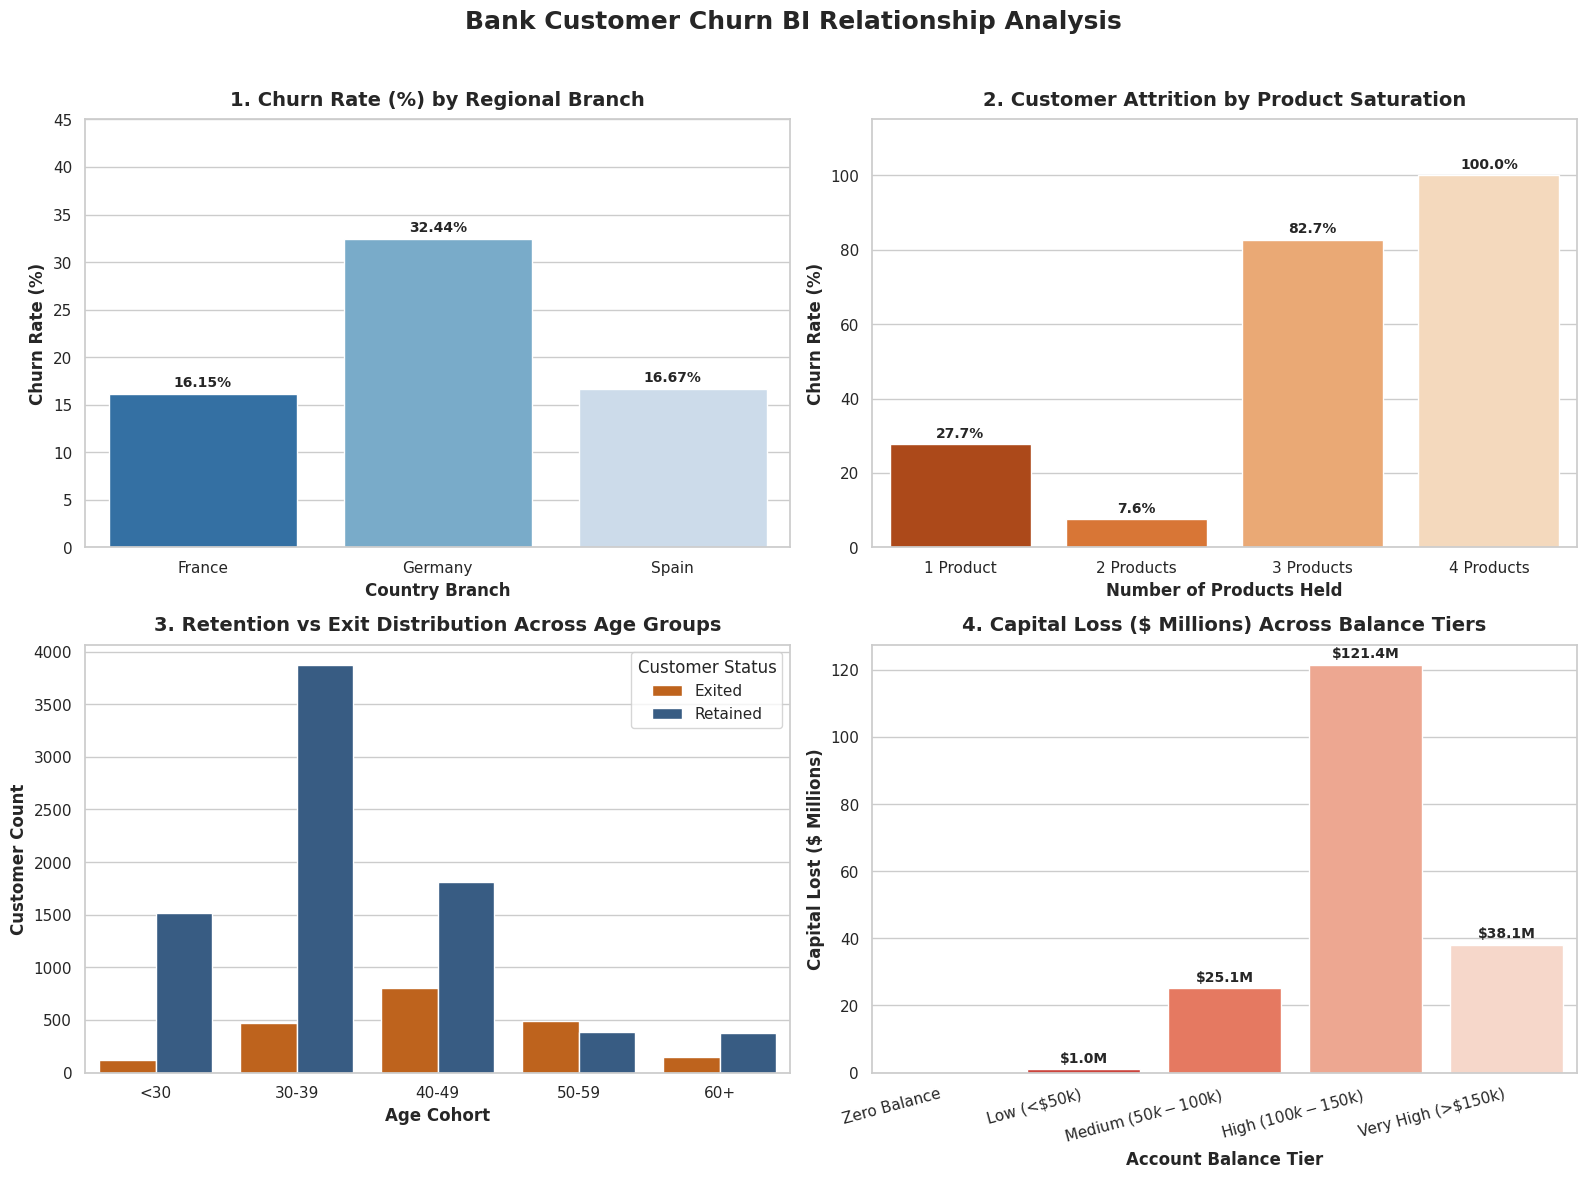

[+] Relationship dashboard image generated and saved to: 'BI_Customer_Churn_Relationships.png'


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Bank_Customer_Churn_Prediction.csv")

duplicates_count = df.duplicated().sum()
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"[-] Removed {duplicates_count} duplicate records.")
else:
    print("[+] Data integrity check passed: 0 duplicate records found.")


df = df.copy()

string_cols = ['country', 'gender']
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

df['customer_id'] = df['customer_id'].astype(str)

df['churn_status'] = df['churn'].map({0: 'Retained', 1: 'Exited'})
df['activity_status'] = df['active_member'].map({0: 'Inactive Member', 1: 'Active Member'})
df['has_credit_card'] = df['credit_card'].map({0: 'No Credit Card', 1: 'Has Credit Card'})

age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['<30', '30-39', '40-49', '50-59', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

balance_bins = [-1, 0, 50000, 100000, 150000, np.inf]
balance_labels = ['Zero Balance', 'Low (<$50k)', 'Medium ($50k-$100k)', 'High ($100k-$150k)', 'Very High (>$150k)']
df['balance_tier'] = pd.cut(df['balance'], bins=balance_bins, labels=balance_labels)

credit_bins = [0, 580, 670, 740, 850]
credit_labels = ['Poor (<580)', 'Fair (580-669)', 'Good (670-739)', 'Excellent (740+)']
df['credit_tier'] = pd.cut(df['credit_score'], bins=credit_bins, labels=credit_labels)

df['product_category'] = df['products_number'].map({
    1: '1 Product',
    2: '2 Products',
    3: '3 Products',
    4: '4 Products'
})

df['balance_lost'] = np.where(df['churn'] == 1, df['balance'], 0.0)
df['balance_to_salary_ratio'] = np.round(
    df['balance'] / np.where(df['estimated_salary'] == 0, 1, df['estimated_salary']), 4
)

bi_output_csv = 'Cleaned_Bank_Customer_Churn_BI.csv'
df.to_csv(bi_output_csv, index=False)
print(f"[+] BI ETL pipeline complete. Transformed dataset saved to: '{bi_output_csv}'")


print("\n" + "="*50)
print("             EXECUTIVE BI KPI SUMMARY           ")
print("="*50)

total_cust = len(df)
total_churned = df['churn'].sum()
churn_rate = (total_churned / total_cust) * 100
total_balance_lost = df['balance_lost'].sum()
active_rate = df['active_member'].mean() * 100

print(f"Total Customer Base       : {total_cust:,}")
print(f"Total Churned Customers   : {total_churned:,}")
print(f"Overall Churn Rate (%)    : {churn_rate:.2f}%")
print(f"Total Capital Lost ($)   : ${total_balance_lost:,.2f}")
print(f"Active Member Ratio (%)   : {active_rate:.2f}%")
print("="*50 + "\n")


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bank Customer Churn BI Relationship Analysis', fontsize=18, fontweight='bold', y=0.98)

country_metrics = df.groupby('country').agg(
    churn_rate=('churn', lambda x: x.mean() * 100)
).reset_index()

ax1 = axes[0, 0]
barplot1 = sns.barplot(data=country_metrics, x='country', y='churn_rate', ax=ax1, palette='Blues_r')
ax1.set_title('1. Churn Rate (%) by Regional Branch', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Country Branch', fontweight='bold')
ax1.set_ylabel('Churn Rate (%)', fontweight='bold')
ax1.set_ylim(0, 45)

for p in barplot1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:.2f}%',
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3),
                 textcoords='offset points')

product_metrics = df.groupby('product_category', observed=False).agg(
    churn_rate=('churn', lambda x: x.mean() * 100)
).reset_index()

ax2 = axes[0, 1]
barplot2 = sns.barplot(data=product_metrics, x='product_category', y='churn_rate', ax=ax2, palette='Oranges_r')
ax2.set_title('2. Customer Attrition by Product Saturation', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Number of Products Held', fontweight='bold')
ax2.set_ylabel('Churn Rate (%)', fontweight='bold')
ax2.set_ylim(0, 115)

for p in barplot2.patches:
    height = p.get_height()
    ax2.annotate(f'{height:.1f}%',
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3),
                 textcoords='offset points')

ax3 = axes[1, 0]
age_order = ['<30', '30-39', '40-49', '50-59', '60+']
sns.countplot(
    data=df, x='age_group', hue='churn_status', order=age_order, 
    ax=ax3, palette={'Retained': '#2b5c8f', 'Exited': '#d95f02'}
)
ax3.set_title('3. Retention vs Exit Distribution Across Age Groups', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Age Cohort', fontweight='bold')
ax3.set_ylabel('Customer Count', fontweight='bold')
ax3.legend(title='Customer Status', frameon=True)

balance_metrics = df.groupby('balance_tier', observed=False).agg(
    total_lost=('balance_lost', lambda x: x.sum() / 1e6)
).reset_index()

ax4 = axes[1, 1]
barplot4 = sns.barplot(data=balance_metrics, x='balance_tier', y='total_lost', ax=ax4, palette='Reds_r')
ax4.set_title('4. Capital Loss ($ Millions) Across Balance Tiers', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Account Balance Tier', fontweight='bold')
ax4.set_ylabel('Capital Lost ($ Millions)', fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=15, ha='right')

for p in barplot4.patches:
    height = p.get_height()
    if height > 0:
        ax4.annotate(f'${height:.1f}M',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3),
                     textcoords='offset points')

plt.tight_layout(rect=[0, 0, 1, 0.96])
output_image = 'BI_Customer_Churn_Relationships.png'
plt.savefig(output_image, dpi=300)
plt.show()

print(f"[+] Relationship dashboard image generated and saved to: '{output_image}'")